In [ ]:
!pip install pytesseract
import cv2
import pytesseract


In [ ]:
image = cv2.imread('/content/ocr.png')


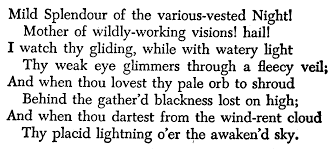

In [ ]:
from google.colab.patches import cv2_imshow
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

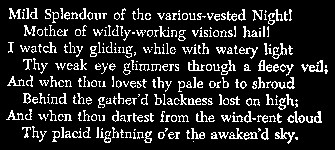

In [ ]:
thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)[1]

cv2_imshow(thresh)

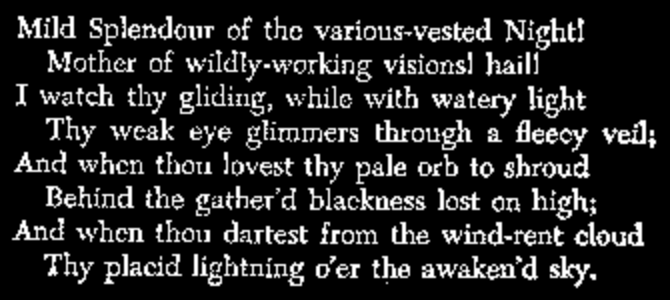

In [ ]:
resized = cv2.resize(thresh, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
cv2_imshow(resized)

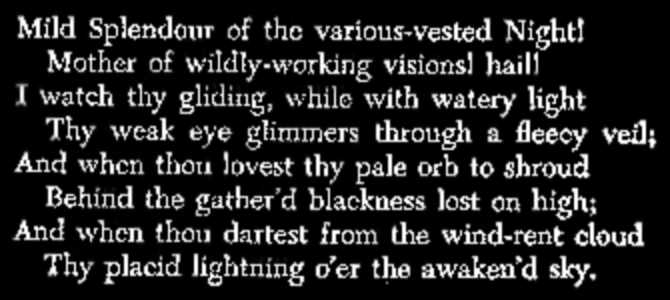

In [ ]:
denoised = cv2.fastNlMeansDenoising(resized, None, 30, 25, 40)
cv2_imshow(denoised)

In [ ]:
text = pytesseract.image_to_string(denoised, lang='eng')

print(text)

otis Myebl eee Mo Merem Zs stolioa cs MNiTu sL}
Mother of wildty-working visions) haill
Pcie cr mesbeceecemc ast oMuZ RCC sam (tid
Thy weak eye glimmers through a fleecy veil;
And when thou lovest thy pale orb to shroud
Behind the gather’d blackness lost on high;
And when thou dartest from the wind-rent cloud
Thy placid lightning o’er the awaken’d sky,



In [ ]:
!pip install easyocr

In [ ]:
import easyocr

reader = easyocr.Reader(['en']) # 'en' for English

easyocr_text_results = reader.readtext(denoised)

# easyocr returns a list of tuples, each containing (bbox, text, confidence)
# Let's extract and print only the text
print("Text extracted by EasyOCR:")
for (bbox, text, prob) in easyocr_text_results:
    print(text)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text extracted by EasyOCR:
Mild Splendour of thc various-vested Nightf
Mother of wildly-working visionsl haill
I watch thy gliding, whilc with
light
Thy wcak eye glimmers through
ved;
And whcn thou Jovest thy
orb to shroud
Behind the
gather d blackuess Jost on high;
And whcn thou dartest from the wind-rent cloud
Thy placid lightning %er the awakend sky.
watery
feecy
pale


Visualizing EasyOCR Bounding Boxes:


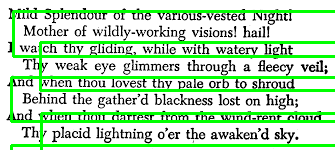

In [ ]:
import numpy as np

# Make a copy of the original image to draw on
image_with_easyocr_boxes = image.copy()

print("Visualizing EasyOCR Bounding Boxes:")
for (bbox, text, prob) in easyocr_text_results:
    # easyocr bounding box format: [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
    # We need (startX, startY) and (endX, endY) for cv2.rectangle
    # The bbox coordinates are float, so convert to int
    top_left = (int(bbox[0][0]), int(bbox[0][1]))
    bottom_right = (int(bbox[2][0]), int(bbox[2][1]))

    cv2.rectangle(image_with_easyocr_boxes, top_left, bottom_right, (0, 255, 0), 2) # Green rectangle
    # Optionally, put the detected text above the box
    # cv2.putText(image_with_easyocr_boxes, text, (top_left[0], top_left[1] - 10),
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

cv2_imshow(image_with_easyocr_boxes)

In [ ]:
import cv2

# Open the default webcam (0 = built-in webcam)
cap = cv2.VideoCapture(0)

while cap.isOpened():
    # Read a frame from the webcam
    ret, frame = cap.read()

    # Load the Haar Cascade face detector
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    if ret:
        # Convert the frame to grayscale
        grey = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Display the grayscale video
        cv2.imshow("Video", grey)

        # Press 'q' to exit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        break

# Release the webcam
cap.release()

# Close all OpenCV windows
cv2.destroyAllWindows()

### Working with Webcam in Google Colab

As mentioned, direct live video streaming with `cv2.VideoCapture(0)` and `cv2.imshow()` is generally not supported in Google Colab notebooks. However, we can use `google.colab.widgets.Webcam` to capture still images from your webcam, which can then be processed by OpenCV.

This approach allows you to take a snapshot from your webcam and apply image processing or computer vision tasks to that static image.

In [ ]:
import cv2
import numpy as np
import io
import base64
from IPython.display import display, Javascript, Image
from google.colab.patches import cv2_imshow # For displaying OpenCV images in Colab

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Photo';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Resize the output to fit the display
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // Wait for button to click
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

print('Click the "Capture Photo" button below to take a picture from your webcam.')
try:
    # Call the JavaScript function to capture a photo
    image_filename = take_photo('webcam_capture.jpg')
    print(f'Photo captured and saved as {image_filename}')
    # Read the captured image into OpenCV format
    global captured_image # Make the image accessible globally
    captured_image = cv2.imread(image_filename)
    if captured_image is not None:
        print("Image captured successfully!")
        cv2_imshow(captured_image)
    else:
        print("Failed to read captured image.")
except Exception as err:
    print(str(err))
    print("An error occurred while trying to capture the photo. Please ensure browser permissions for webcam are granted.")

Click the "Capture Photo" button below to take a picture from your webcam.


<IPython.core.display.Javascript object>

name 'eval_js' is not defined
An error occurred while trying to capture the photo. Please ensure browser permissions for webcam are granted.


Once you've captured an image, the `captured_image` variable will hold the OpenCV image. You can then apply the grayscale conversion and face detection steps as follows:

In [ ]:
# Ensure an image has been captured before proceeding

if 'captured_image' in globals() and captured_image is not None:
    print("Processing captured image...")

    # Convert the captured frame to grayscale
    gray_frame = cv2.cvtColor(captured_image, cv2.COLOR_BGR2GRAY)
    print("Grayscale image from webcam:")
    cv2_imshow(gray_frame)

    # Load the Haar Cascade face detector
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    # Detect faces in the grayscale image
    faces = face_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw rectangles around the detected faces on a copy of the original captured image
    image_with_faces = captured_image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(image_with_faces, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle

    print(f"Detected {len(faces)} face(s).")
    print("Image with detected faces:")
    cv2_imshow(image_with_faces)
else:
    print("No image captured yet or failed to capture. Please execute the previous cell and click the 'Capture Photo' button.")
    print("If no button appears, you might need to run the cell again or check browser permissions for webcam access.")

No image captured yet or failed to capture. Please execute the previous cell and click the 'Capture Photo' button.
If no button appears, you might need to run the cell again or check browser permissions for webcam access.
